# Telemetry Data Visualisation

Given Raw Data from Sensors of an aircraft of a particular flight, my mission is to use those data to create a data visualiser of the path of the aircraft.

# Upload Raw Telemetry Data

In [3]:
import pandas as pd

raw_data = pd.read_csv('bushmaster-8-4-26(in).csv')

display(raw_data.head(3))


,status,timestamp_ms,rtc_iso8601,rtc_unix,pressure_hpa,temperature_c,altitude_m,acc_x,acc_y,acc_z,...,gnss_speed_acc_mps,gnss_heading_deg,gnss_heading_acc_deg,log_dt_ms,log_overrun_count,sd_write_error_count,baro_age_ms,gnss_age_ms,airspeed_age_ms,esc_age_ms
0,LOGGING,407982,2026-04-06T17:57:59,1775498279,993.76,33.53,163.54,1.272,1.797,9.227,...,0,0,0,0,6,0,1,-1,-1,-1
1,LOGGING,408024,2026-04-06T17:57:59,1775498279,993.76,33.53,163.54,1.273,1.797,9.225,...,0,0,0,42,6,0,43,-1,-1,-1
2,LOGGING,408061,2026-04-06T17:57:59,1775498279,993.76,33.53,163.54,1.275,1.797,9.228,...,0,0,0,37,6,0,1,-1,-1,-1


# 3D Path Visualisation

I'm going to use ekf_x_m, ekf_y_m and altitude_m to plot the coordinates of the plane at each point in time.

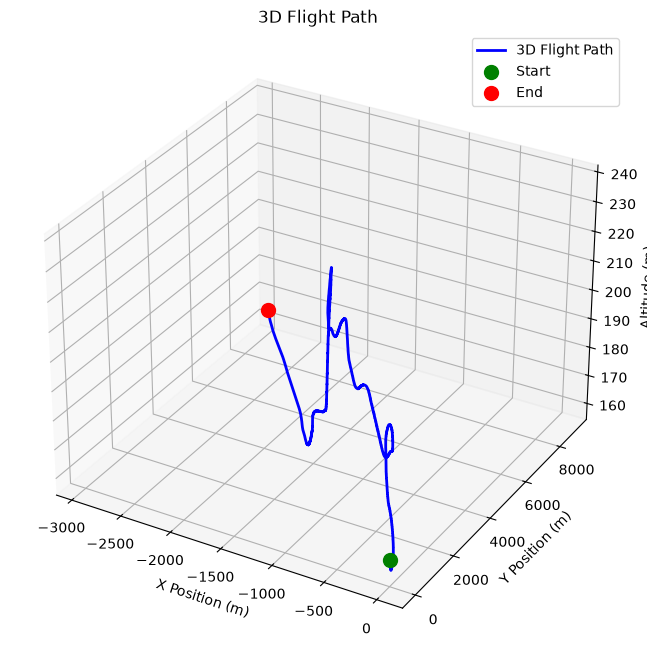

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting the data
ax.plot(raw_data['ekf_x_m'], raw_data['ekf_y_m'], raw_data['altitude_m'], 
        linewidth=2, color='blue', label='3D Flight Path')

# Mark start and end
ax.scatter(raw_data['ekf_x_m'].iloc[0], raw_data['ekf_y_m'].iloc[0], 
           raw_data['altitude_m'].iloc[0], color='green', s=100, label='Start')
ax.scatter(raw_data['ekf_x_m'].iloc[-1], raw_data['ekf_y_m'].iloc[-1],
           raw_data['altitude_m'].iloc[-1], color='red', s=100, label='End')

# Axes
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Altitude (m)')
ax.set_title('3D Flight Path')

ax.legend()
plt.show()

/tmp/ipykernel_1973/3666549460.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_data['time_sec'] = raw_data['timestamp_ms'] / 1000


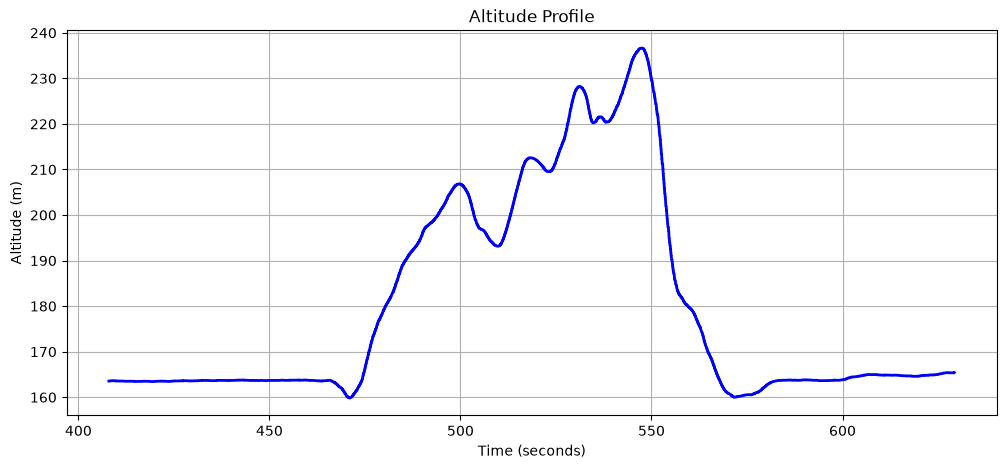

In [8]:
raw_data['time_sec'] = raw_data['timestamp_ms'] / 1000

plt.figure(figsize=(12, 5))
plt.plot(raw_data['time_sec'], raw_data['altitude_m'], linewidth=2, color='blue')
plt.xlabel('Time (seconds)')
plt.ylabel('Altitude (m)')
plt.title('Altitude Profile')
plt.grid(True)
plt.show()

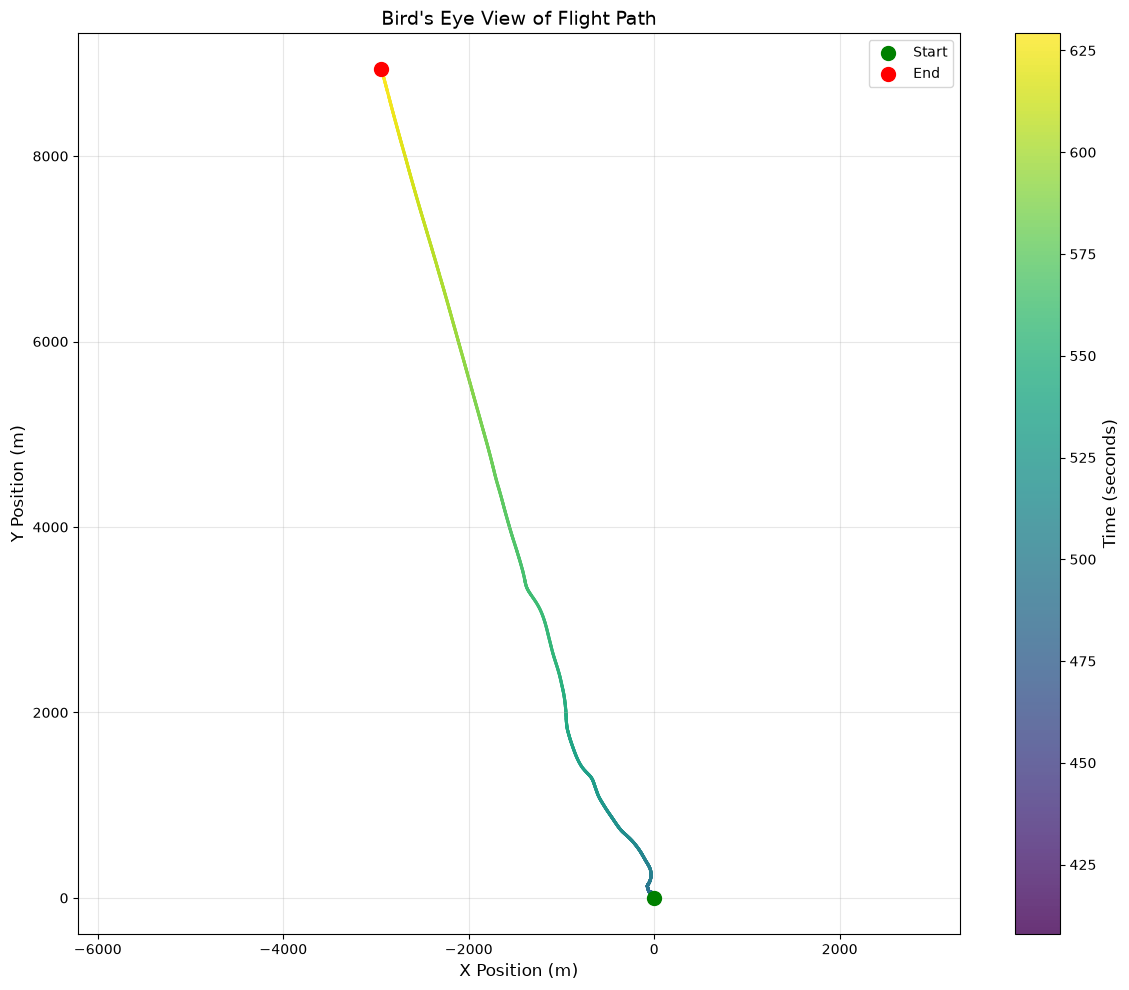

In [13]:
plt.figure(figsize=(12, 10))

# Scatter plot with time-based colour gradient
scatter = plt.scatter(raw_data['ekf_x_m'], raw_data['ekf_y_m'], 
                      c=raw_data['time_sec'], cmap='viridis', 
                      s=5, alpha=0.8, linewidth=0)

# Add colourbar to show time
cbar = plt.colorbar(scatter)
cbar.set_label('Time (seconds)', fontsize=12)

# Mark start and end
plt.scatter(raw_data['ekf_x_m'].iloc[0], raw_data['ekf_y_m'].iloc[0], 
            color='green', s=100, label='Start', zorder=5)
plt.scatter(raw_data['ekf_x_m'].iloc[-1], raw_data['ekf_y_m'].iloc[-1], 
            color='red', s=100, label='End', zorder=5)

plt.xlabel('X Position (m)', fontsize=12)
plt.ylabel('Y Position (m)', fontsize=12)
plt.title('Bird\'s Eye View of Flight Path', fontsize=14)
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()